# 03 — Training runner

This notebook runs training from a selected config. The notebook itself
is shared for all experiments; the chosen config string selects the
run.

If you want parallel work, open multiple Colab sessions on the same
notebook and each session picks a different `RUN` value.


## Environment setup

This notebook is not one run per file. Instead:

- one notebook = one runner
- one config = one experiment
- different people can use the same notebook with different config values

In Colab, the notebook runs on a remote VM. If the repo is not already
available there, this notebook will clone it from GitHub. It also stages
data from the shared Drive archive into `/content/data` using the
paths defined in `configs/paths.yaml`.


In [1]:
from pathlib import Path
import subprocess
import sys
import torch
import zipfile

REPO_URL = "https://github.com/FilippoIsoni/sharp-har.git"

# Locate or clone the repository root containing the sharp_har package.
# In Colab, the notebook may run from a temporary working directory.
cwd = Path.cwd().resolve()
if (cwd / "sharp_har").exists():
    REPO_DIR = cwd
elif (cwd.parent / "sharp_har").exists():
    REPO_DIR = cwd.parent
elif (cwd.parent.parent / "sharp_har").exists():
    REPO_DIR = cwd.parent.parent
else:
    REPO_DIR = Path("/content/sharp-har")
    if not REPO_DIR.exists():
        REPO_DIR.parent.mkdir(parents=True, exist_ok=True)
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

sys.path.insert(0, str(REPO_DIR))

from google.colab import drive
from sharp_har.train import train_run
from sharp_har.utils import read_yaml

paths_cfg = read_yaml(REPO_DIR / "configs" / "paths.yaml")
drive_root = Path(paths_cfg["drive_root"])
stage_dir = Path(paths_cfg["stage_dir"])
CKPT_ROOT = Path(paths_cfg["ckpt_root"])

# Mount Drive and stage the zip archives if needed.
# This follows the project convention in 00_setup_smoke.ipynb.
if not (stage_dir.exists() and any(stage_dir.rglob("*.txt"))):
    drive.mount("/content/drive")
    stage_dir.mkdir(parents=True, exist_ok=True)
    for zip_name in paths_cfg["zips"]:
        src = drive_root / zip_name
        dst = Path("/content") / zip_name
        print(f"copying {src} -> {dst}")
        subprocess.run(["cp", str(src), str(dst)], check=True)
        with zipfile.ZipFile(dst) as zf:
            zf.extractall(stage_dir)

print("Repo dir:", REPO_DIR)
print("sharp_har exists:", (REPO_DIR / "sharp_har").exists())
print("GPU available:", torch.cuda.is_available())
print("Stage dir:", stage_dir)
print("Checkpoint root:", CKPT_ROOT)


Mounted at /content/drive
copying /content/drive/MyDrive/DATASET_SHARP/doppler_traces.zip -> /content/doppler_traces.zip
copying /content/drive/MyDrive/DATASET_SHARP/doppler_traces_S4_S5.zip -> /content/doppler_traces_S4_S5.zip
Repo dir: /content/sharp-har
sharp_har exists: True
GPU available: True
Stage dir: /content/data
Checkpoint root: /content/drive/MyDrive/sharp_har_runs


## Load config and launch the run

Choose one config stem below and run the cell. The config name
determines which experiment is executed.


In [2]:
RUN = "c1_ce"  # choose one of c0_sharp, c1_ce, c2_grl, c3_supcon, c4_supcon_grl
cfg = read_yaml(REPO_DIR / "configs" / f"{RUN}.yaml")

print("Selected run:", RUN)
print("Config summary:")
print(cfg)

out = train_run(cfg, stage_dir=stage_dir, ckpt_dir=CKPT_ROOT, repo_dir=REPO_DIR)
print("Train run finished:", out)


2026-07-16 13:15:40,721 [INFO] sharp_har.data: train: 81 traces, 53400 (window, antenna) samples (win=340, stride=100)
2026-07-16 13:15:40,738 [INFO] sharp_har.data: val: 9 traces, 1396 (window, antenna) samples (win=340, stride=340)


Selected run: c1_ce
Config summary:
{'name': 'C1', 'protocol': 'P2-lab', 'split_file': 'splits/p2_lab.json', 'backbone': 'resnet_vb', 'd_enc': 256, 'n_att': 8, 'loss': {'type': 'ce', 'label_smoothing': 0.1}, 'adversary': {'type': None, 'target': 'ar_set', 'lambda_max': None, 'beta': None}, 'optim': {'name': 'adamw', 'lr': 0.001, 'wd': 0.0001, 'warmup_epochs': 5, 'scheduler': 'cosine'}, 'train': {'epoch_steps': 400, 'max_epochs': 40, 'batch_size': 256, 'sampler': 'uniform', 'amp': True, 'grad_clip': 1.0}, 'eval': {'select_metric': 'val_macro_f1', 'patience': 10}}


2026-07-16 13:20:13,424 [INFO] sharp_har.train: C1 epoch 1/40: loss 1.5980, val macro-F1 0.1179, 0.654 s/step
2026-07-16 13:24:15,917 [INFO] sharp_har.train: C1 epoch 2/40: loss 1.3747, val macro-F1 0.4306, 0.599 s/step
2026-07-16 13:28:16,232 [INFO] sharp_har.train: C1 epoch 3/40: loss 1.2466, val macro-F1 0.5089, 0.594 s/step
2026-07-16 13:32:15,157 [INFO] sharp_har.train: C1 epoch 4/40: loss 1.1828, val macro-F1 0.7332, 0.591 s/step
2026-07-16 13:36:10,878 [INFO] sharp_har.train: C1 epoch 5/40: loss 1.1439, val macro-F1 0.1185, 0.582 s/step
2026-07-16 13:40:07,716 [INFO] sharp_har.train: C1 epoch 6/40: loss 1.1020, val macro-F1 0.1535, 0.586 s/step
2026-07-16 13:44:02,975 [INFO] sharp_har.train: C1 epoch 7/40: loss 1.0624, val macro-F1 0.6852, 0.581 s/step
2026-07-16 13:47:56,785 [INFO] sharp_har.train: C1 epoch 8/40: loss 1.0245, val macro-F1 0.4295, 0.578 s/step
2026-07-16 13:51:51,578 [INFO] sharp_har.train: C1 epoch 9/40: loss 0.9915, val macro-F1 0.7416, 0.581 s/step
2026-07-16

Train run finished: {'run_dir': PosixPath('/content/drive/MyDrive/sharp_har_runs/C1'), 'best_val_macro_f1': 0.88705950443352, 'history': [{'epoch': 1, 'train_loss': 1.598037567138672, 'val_macro_f1': 0.11793277384006609, 'lr': 0.00020050000000000002, 's_per_step': 0.6542948412895203, 'epoch_seconds': 261.7179365158081}, {'epoch': 2, 'train_loss': 1.374705158472061, 'val_macro_f1': 0.4306073112207768, 'lr': 0.00040050000000000003, 's_per_step': 0.5992601096630097, 'epoch_seconds': 239.70404386520386}, {'epoch': 3, 'train_loss': 1.2465816310048103, 'val_macro_f1': 0.5089334081474521, 'lr': 0.0006005, 's_per_step': 0.5935552948713303, 'epoch_seconds': 237.4221179485321}, {'epoch': 4, 'train_loss': 1.1828293845057487, 'val_macro_f1': 0.7332102871596735, 'lr': 0.0008005, 's_per_step': 0.5912265574932098, 'epoch_seconds': 236.49062299728394}, {'epoch': 5, 'train_loss': 1.1438778510689736, 'val_macro_f1': 0.11853720050441363, 'lr': 0.001, 's_per_step': 0.5820832997560501, 'epoch_seconds': 232

TRAINING CURVES

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def plot_run_metrics(run_dir: Path):
    hist_path = run_dir / "history.csv"
    if not hist_path.exists():
        print("history.csv non trovato:", hist_path)
        return

    hist = pd.read_csv(hist_path)
    fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    ax = axes.ravel()

    ax[0].plot(hist["epoch"], hist["train_loss"], marker="o")
    ax[0].set_title("Train Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].grid(True)

    if "val_macro_f1" in hist.columns:
        ax[1].plot(hist["epoch"], hist["val_macro_f1"], marker="o", color="green")
        ax[1].set_title("Val Macro-F1")
        ax[1].set_xlabel("Epoch")
        ax[1].set_ylabel("Macro-F1")
        ax[1].grid(True)
    else:
        ax[1].set_visible(False)

    if "arset_train_acc" in hist.columns:
        ax[2].plot(hist["epoch"], hist["arset_train_acc"], marker="o", color="red")
        ax[2].set_title("AR-set Train Accuracy")
        ax[2].set_xlabel("Epoch")
        ax[2].set_ylabel("Accuracy")
        ax[2].grid(True)
    else:
        ax[2].set_visible(False)

    if "grl_lambda" in hist.columns:
        ax[3].plot(hist["epoch"], hist["grl_lambda"], marker="o", color="brown")
        ax[3].set_title("GRL λ")
        ax[3].set_xlabel("Epoch")
        ax[3].set_ylabel("λ")
        ax[3].grid(True)
    else:
        ax[3].set_visible(False)

    if "lr" in hist.columns:
        ax[4].plot(hist["epoch"], hist["lr"], marker="o", color="purple")
        ax[4].set_title("Learning Rate")
        ax[4].set_xlabel("Epoch")
        ax[4].set_ylabel("LR")
        ax[4].grid(True)
    else:
        ax[4].set_visible(False)

    ax[5].plot(hist["epoch"], hist["s_per_step"], marker="o", color="orange")
    ax[5].set_title("Seconds per Step")
    ax[5].set_xlabel("Epoch")
    ax[5].set_ylabel("s/step")
    ax[5].grid(True)

    fig.suptitle(f"Run: {run_dir.name}", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

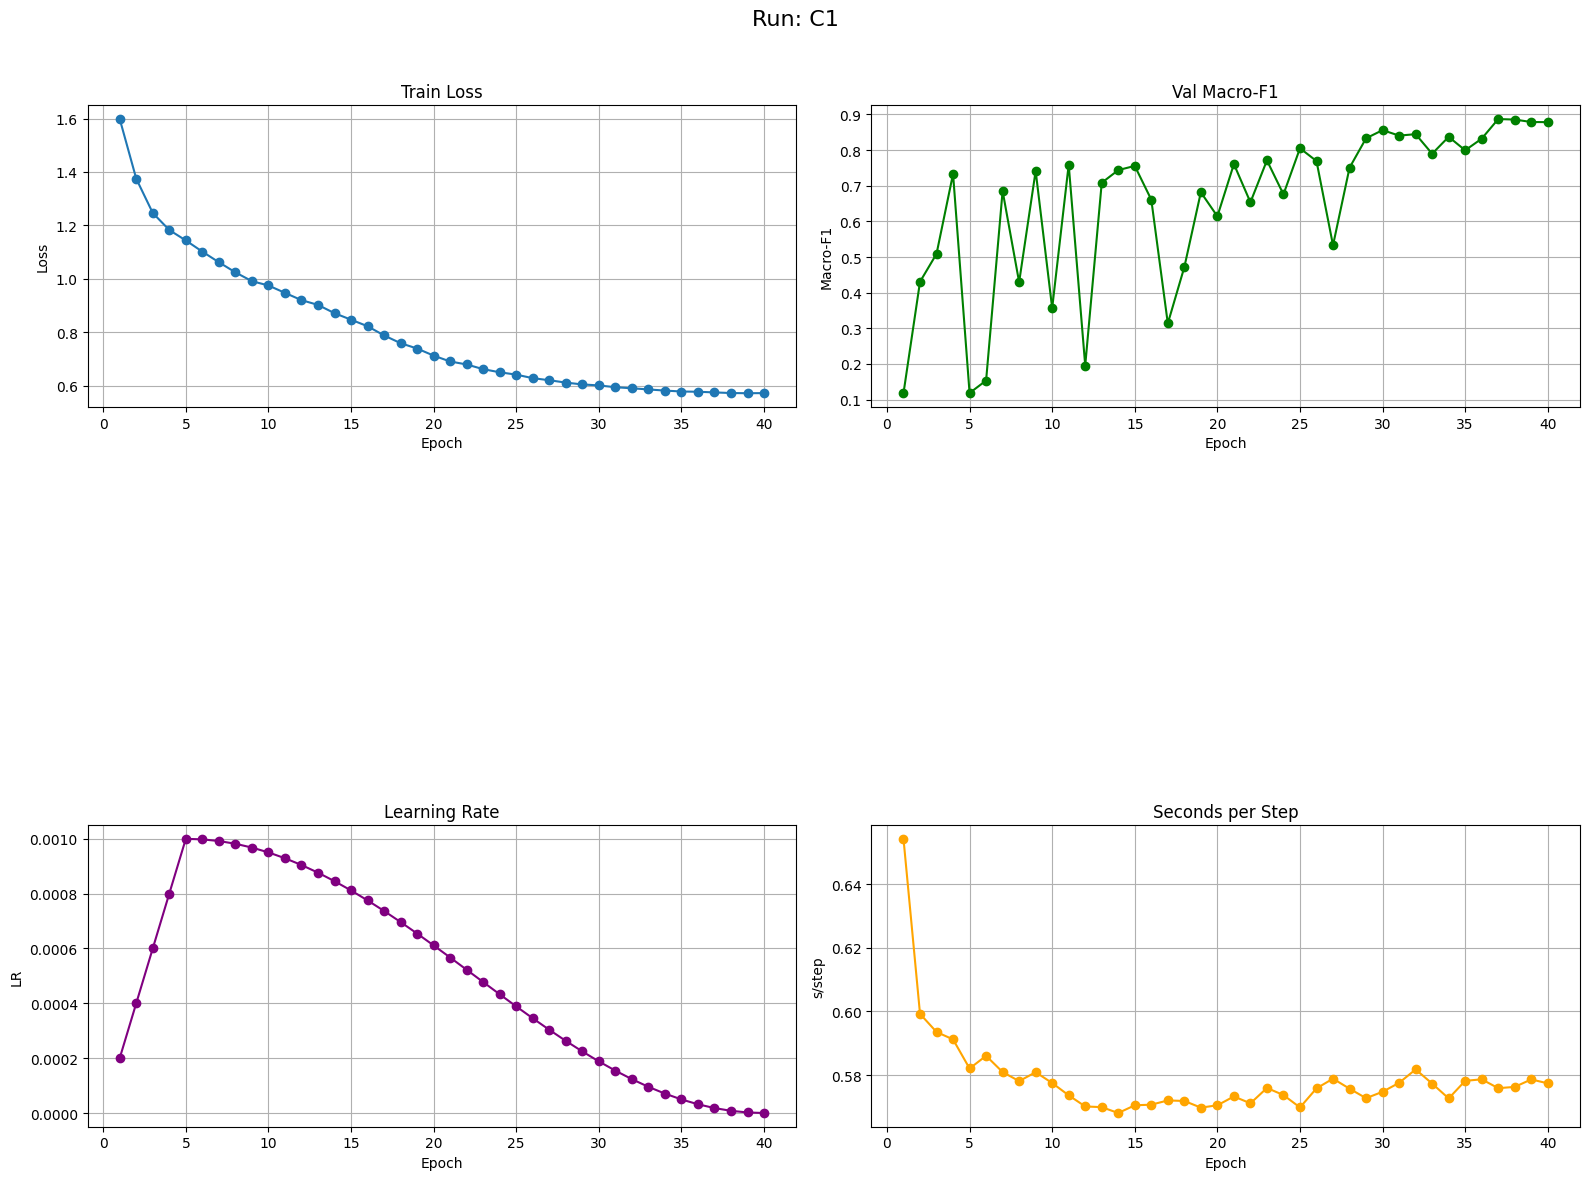

In [12]:
# Cell 2: chiamata
run_dir = CKPT_ROOT / cfg["name"]
plot_run_metrics(run_dir)